In [6]:
from pathlib import Path
import sys
from time import time

# Allows the notebook to import files from the project root.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots
from src.preprocessing import load_csv, preprocess_data
from src.instantaneous_methods import velocity_magnitude_method
from src.instantaneous_methods import (
    velocity_magnitude_method,
    velocity_acceleration_method,
    energy_method,
    work_method, paddle_method,
)
from src.interval_based_methods import (
    partition_data,
    partitioned_average_over_interval
)

In [8]:
file_path = PROJECT_ROOT / "data" / "LogAllData07-06_15-54-30.csv"

df = load_csv(file_path)
data = preprocess_data(df, do_savgol=True)

In [9]:
import numpy as np

bucket_size = 5
VM = velocity_magnitude_method(data)
energy = energy_method(data,hand_mass=0.4,kinetic_weight=0.85)
work = work_method(data,hand_mass=0.4)
paddle = paddle_method(data)
print(np.asarray(paddle[0]).shape)
results = {
    "Velocity Magnitude Method": partition_data(
        data,
        VM[0],
        bucket_size=bucket_size,
        value_name="Average VM Exertion",
    ),

    "Energy Method": partition_data(
        data,
        energy[0],
        bucket_size=bucket_size,
        value_name="Average Energy Exertion",
    ),

    "Work Method": partition_data(
        data,
        work[0],
        bucket_size=bucket_size,
        value_name="Average Work Exertion",
    ),

    "Paddle Method": partition_data(
        data,
        paddle[0],
        bucket_size=bucket_size,
        value_name="Average Paddle Exertion",
    ),
}

(88933, 1)


Plotting

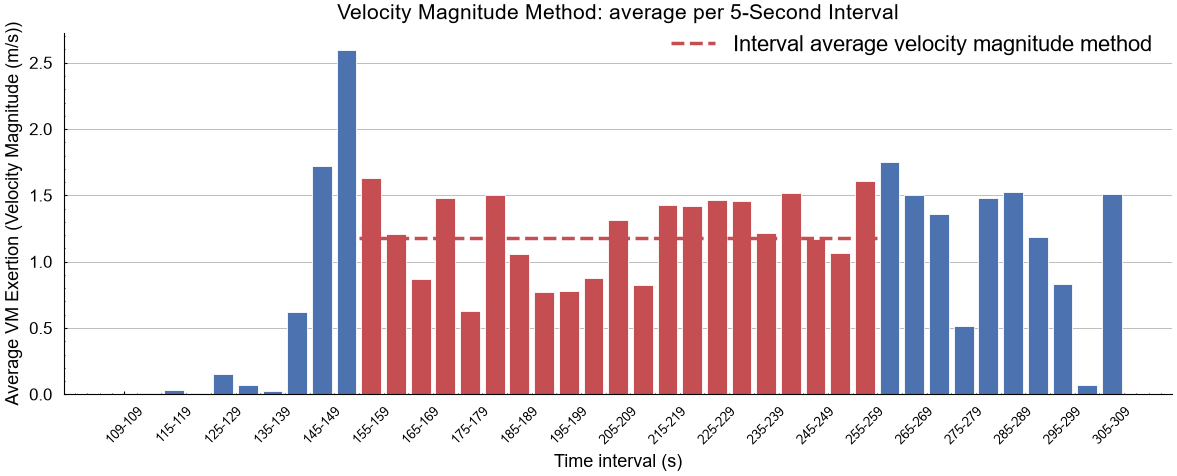

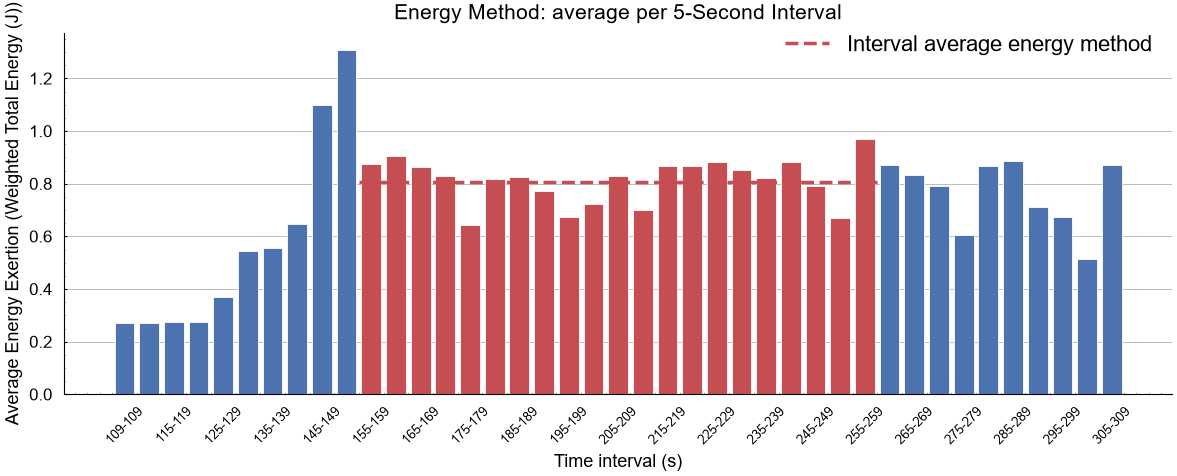

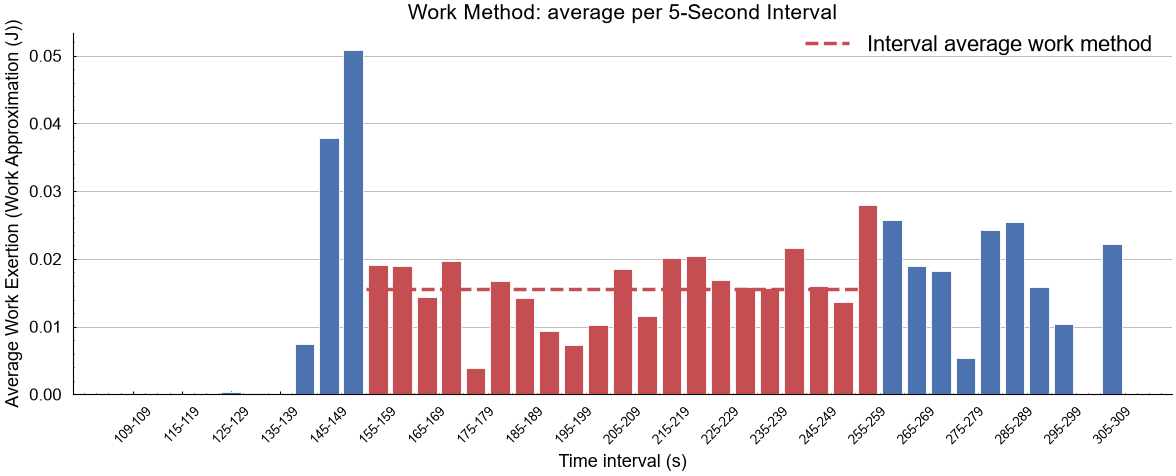

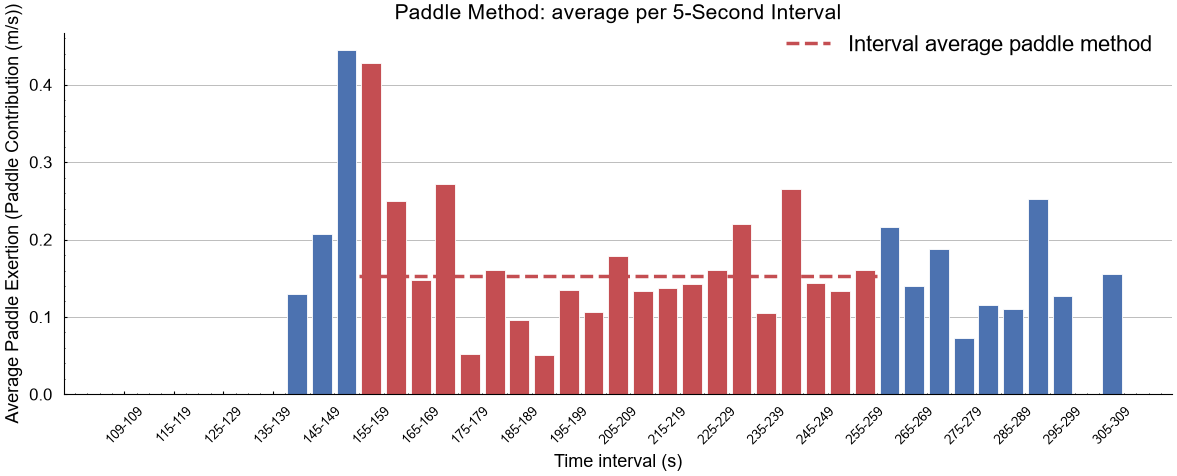

In [10]:
from formatting_options import plot_style

# Interval used to calculate the average exertion metric
t_1 = data["time"].min() + 50.0
t_2 = t_1 + 100

# Interval displayed on the graph
plot_start_time = data["time"].min()
plot_end_time = plot_start_time + 200

time_min = data["time"].min()
time_max = data["time"].max()

# Validate calculation interval
if t_1 < time_min or t_2 > time_max or t_1 >= t_2:
    raise ValueError(
        "Calculation interval is invalid. Check that:"
        "\n\tt_1 >= min(time)"
        "\n\tt_2 <= max(time)"
        "\n\tt_1 < t_2"
    )

# Validate graph interval
if (
    plot_start_time < time_min
    or plot_end_time > time_max
    or plot_start_time >= plot_end_time
):
    raise ValueError(
        "Plot interval is invalid. Check that:"
        "\n\tplot_start_time >= min(time)"
        "\n\tplot_end_time <= max(time)"
        "\n\tplot_start_time < plot_end_time"
    )

# Raw (dependent, units) pairs used to compute each method's interval average
raw_data = {
    "Velocity Magnitude Method": VM,
    "Energy Method": energy,
    "Work Method": work,
    "Paddle Method": paddle,
}

with plt.style.context(["science", "notebook", "grid", plot_style]):

    for method_name, df_5s in results.items():

        # Column holding the averaged values for this method (everything
        # besides the fixed bucket/time columns produced by partition_data)
        value_col = [
            c for c in df_5s.columns
            if c not in ("bucket", "start_time", "end_time", "bucket_length")
        ][0]

        dependent, units = raw_data[method_name]

        interval_avg = partitioned_average_over_interval(
            data,
            dependent,
            t_1,
            t_2,
        )

        labels = [
            f"{int(s)}-{int(e)}"
            for s, e in zip(df_5s["start_time"], df_5s["end_time"])
        ]

        # Buckets included in the calculation interval
        calculation_mask = (
            (df_5s["end_time"] >= t_1)
            & (df_5s["start_time"] <= t_2)
        )

        # Buckets shown on the graph
        plot_mask = ((df_5s["end_time"] >= plot_start_time) & (df_5s["start_time"] <= plot_end_time))

        plot_df = df_5s.loc[plot_mask].copy()
        plot_labels = [f"{int(s)}-{int(e)}" for s, e in zip(plot_df["start_time"], plot_df["end_time"])]

        colors = ['#C44E52' if is_in_interval else '#4C72B0' for is_in_interval in calculation_mask.loc[plot_df.index]]

        fig, ax = plt.subplots(figsize=(12, 5))

        ax.bar(plot_labels, plot_df[value_col], color=colors, edgecolor='white', linewidth=0.6)

        # Positions of the red bars within the displayed subset
        interval_positions = [
            i
            for i, is_in_interval in enumerate(
                calculation_mask.loc[plot_df.index]
            )
            if is_in_interval
        ]

        if interval_positions:
            ax.hlines(
                y=interval_avg,
                xmin=min(interval_positions) - 0.5,
                xmax=max(interval_positions) + 0.5,
                color='#C44E52',
                linestyle="--",
                linewidth=2.5,
                label=f"Interval average {method_name.lower()}"
            )

        #grid
        ax.grid(axis='y', linewidth=0.6, alpha=0.3)
        ax.grid(axis='x', visible=False)

        ax.tick_params(which='both', top=False, right=False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_xlabel("Time interval (s)")
        ax.set_ylabel(f"{value_col} ({units})")
        ax.set_title(
            f"{method_name}: average per {bucket_size:g}-Second Interval"
        )

        ax.set_xticks(ax.get_xticks()[::2])

        ax.tick_params(axis="x", rotation=45)
        ax.legend()
        ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.05))

        fig.tight_layout()
        plt.show()